In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision.datasets import ImageFolder

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [4]:
train_full = torchvision.datasets.CIFAR10(
    root='/kaggle/input/datasets/karemsaeed/cifar-10-batches-py', train=True, download=False, transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='/kaggle/input/datasets/karemsaeed/cifar-10-batches-py', train=False, download=False, transform=test_transform
)

In [5]:
print("Total samples:", len(train_full) + len(test_dataset))
print("Train samples:", len(train_full))
print("Test samples:", len(test_dataset))
print("Number of classes:", len(train_full.classes))
print("Classes:", train_full.classes)

sample_img, _ = train_full[0]
print("Image shape:", sample_img.shape)

Total samples: 60000
Train samples: 50000
Test samples: 10000
Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape: torch.Size([3, 224, 224])


In [6]:
indices = list(range(len(train_full)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_dataset = Subset(train_full, train_idx)
val_dataset = Subset(train_full, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
print(device)

cuda


In [9]:
model = torchvision.models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


In [10]:
def validate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total

In [11]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    val_acc = validate(model, val_loader)
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Loss: 1422.2576 | Val Acc: 0.6833
Epoch 2 | Loss: 873.5057 | Val Acc: 0.7890
Epoch 3 | Loss: 688.3475 | Val Acc: 0.8269
Epoch 4 | Loss: 589.3601 | Val Acc: 0.8132
Epoch 5 | Loss: 510.3957 | Val Acc: 0.8538
Epoch 6 | Loss: 460.5449 | Val Acc: 0.8453
Epoch 7 | Loss: 408.1752 | Val Acc: 0.8660
Epoch 8 | Loss: 364.2600 | Val Acc: 0.8943
Epoch 9 | Loss: 330.6870 | Val Acc: 0.8666
Epoch 10 | Loss: 302.8678 | Val Acc: 0.8789


In [12]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

y_true_dl, y_pred_dl = evaluate_model(model, test_loader)

In [13]:
print("\n=== DL MODEL RESULTS ===")
accuracy_dl = accuracy_score(y_true_dl, y_pred_dl)
precision_dl = precision_score(y_true_dl, y_pred_dl, average='weighted')
recall_dl = recall_score(y_true_dl, y_pred_dl, average='weighted')
f1_dl = f1_score(y_true_dl, y_pred_dl, average='weighted')

print("Accuracy:", accuracy_dl)
print("Precision:", precision_dl)
print("Recall:", recall_dl)
print("F1-score:", f1_dl)

print(classification_report(y_true_dl, y_pred_dl))


=== DL MODEL RESULTS ===
Accuracy: 0.8803
Precision: 0.8866638111243496
Recall: 0.8803
F1-score: 0.8803224251071468
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1000
           1       0.98      0.87      0.92      1000
           2       0.96      0.76      0.85      1000
           3       0.78      0.79      0.79      1000
           4       0.84      0.91      0.87      1000
           5       0.81      0.84      0.83      1000
           6       0.97      0.83      0.90      1000
           7       0.80      0.97      0.88      1000
           8       0.93      0.96      0.94      1000
           9       0.88      0.97      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



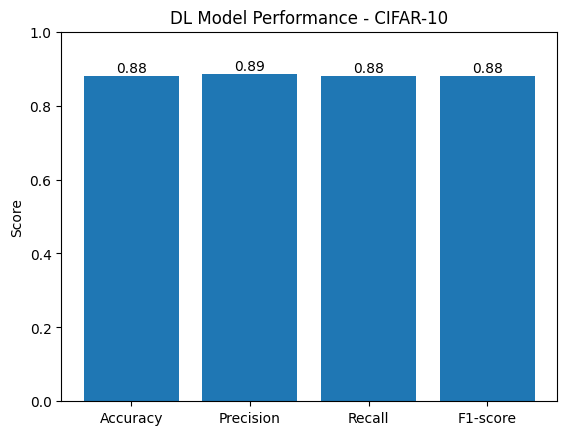

In [14]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [accuracy_dl, precision_dl, recall_dl, f1_dl]

plt.figure()
plt.bar(metrics, values)

plt.title("DL Model Performance - CIFAR-10")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

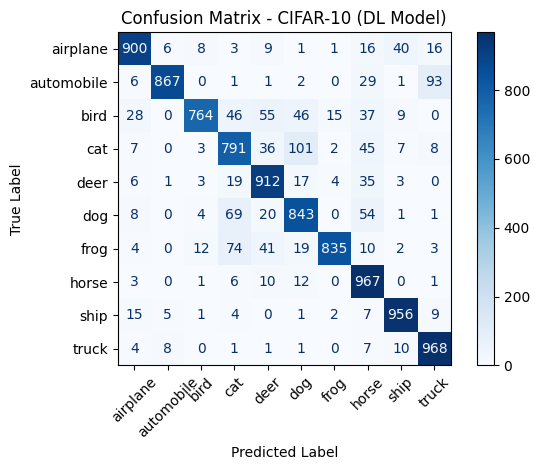

In [15]:
# CIFAR-10 class names (standard order)
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

cm_dl = confusion_matrix(y_true_dl, y_pred_dl)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dl,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - CIFAR-10 (DL Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [16]:
feature_extractor = torchvision.models.resnet50(pretrained=True)
feature_extractor.fc = nn.Identity()
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

def extract_features(loader):
    features, labels_list = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = feature_extractor(images)
            outputs = outputs.view(outputs.size(0), -1)

            features.append(outputs.cpu().numpy())
            labels_list.append(labels.numpy())

    return np.vstack(features), np.hstack(labels_list)

X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train, y_train)

y_pred_ml = svm.predict(X_test)

In [18]:
print("\n=== SVM MODEL RESULTS ===")
accuracy_svm = accuracy_score(y_test, y_pred_ml)
precision_svm = precision_score(y_test, y_pred_ml, average='weighted')
recall_svm = recall_score(y_test, y_pred_ml, average='weighted')
f1_svm = f1_score(y_test, y_pred_ml, average='weighted')

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)

print(classification_report(y_test, y_pred_ml))


=== SVM MODEL RESULTS ===
Accuracy: 0.8118
Precision: 0.815082789345766
Recall: 0.8118
F1-score: 0.8123252287102691
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1000
           1       0.86      0.89      0.87      1000
           2       0.79      0.76      0.78      1000
           3       0.66      0.72      0.69      1000
           4       0.73      0.80      0.76      1000
           5       0.80      0.73      0.76      1000
           6       0.86      0.81      0.84      1000
           7       0.90      0.78      0.83      1000
           8       0.89      0.89      0.89      1000
           9       0.85      0.89      0.86      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



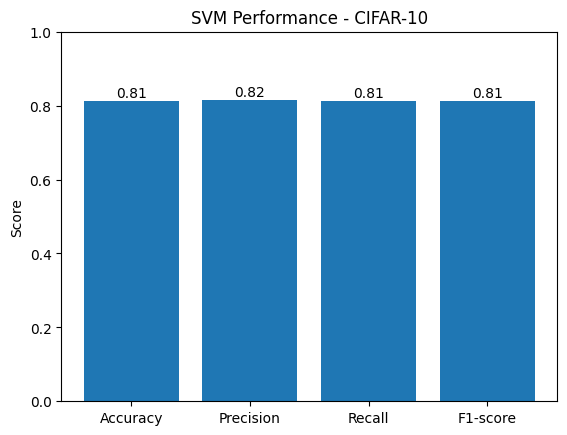

In [19]:
values = [accuracy_svm, precision_svm, recall_svm, f1_svm]

plt.figure()
plt.bar(metrics, values)

plt.title("SVM Performance - CIFAR-10")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

<Figure size 1000x800 with 0 Axes>

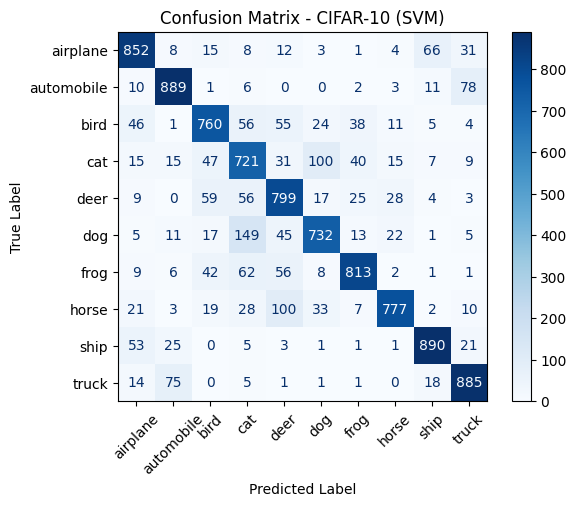

In [20]:
cm_svm = confusion_matrix(y_test, y_pred_ml)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - CIFAR-10 (SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

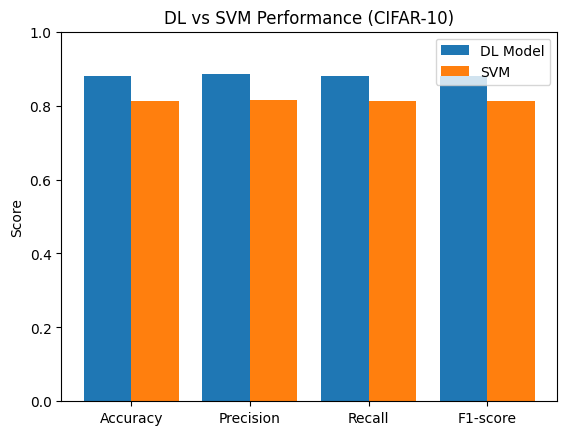

In [21]:
dl_values = [accuracy_dl, precision_dl, recall_dl, f1_dl]
svm_values = [accuracy_svm, precision_svm, recall_svm, f1_svm]

x = range(len(metrics))

plt.figure()

plt.bar(x, dl_values, width=0.4, label='DL Model')
plt.bar([i + 0.4 for i in x], svm_values, width=0.4, label='SVM')

plt.xticks([i + 0.2 for i in x], metrics)
plt.ylim(0, 1)
plt.title("DL vs SVM Performance (CIFAR-10)")
plt.ylabel("Score")
plt.legend()

plt.show()

In [22]:
print("\n==============================")
print("BRAIN TUMOR MRI DATASET")
print("==============================")

train_full_mri = ImageFolder(
    root="/kaggle/input/datasets/karemsaeed/brain-tumor-mri-dataset/brain_tumor_mri_dataset/Training", transform=train_transform)
test_dataset_mri = ImageFolder(
    root="/kaggle/input/datasets/karemsaeed/brain-tumor-mri-dataset/brain_tumor_mri_dataset/Testing", transform=test_transform)

print("Train samples:", len(train_full_mri))
print("Test samples:", len(test_dataset_mri))
print("Classes:", train_full_mri.classes)


BRAIN TUMOR MRI DATASET
Train samples: 5600
Test samples: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [23]:
indices = list(range(len(train_full_mri)))
train_idx_mri, val_idx_mri = train_test_split(indices, test_size=0.2, random_state=42)

train_dataset_mri = Subset(train_full_mri, train_idx_mri)
val_dataset_mri = Subset(train_full_mri, val_idx_mri)

train_loader_mri = DataLoader(train_dataset_mri, batch_size=32, shuffle=True)
val_loader_mri = DataLoader(val_dataset_mri, batch_size=32)
test_loader_mri = DataLoader(test_dataset_mri, batch_size=32)

In [24]:
model_mri = torchvision.models.resnet50(pretrained=True)
num_classes_mri = len(train_full_mri.classes)
model_mri.fc = nn.Linear(model_mri.fc.in_features, num_classes_mri)
model_mri = model_mri.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mri.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
for epoch in range(epochs):
    model_mri.train()
    total_loss = 0

    for images, labels in train_loader_mri:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_mri(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    val_acc = validate(model_mri, val_loader_mri)
    print(f"[MRI] Epoch {epoch+1} | Loss: {total_loss:.4f} | Val Acc: {val_acc:.4f}")

[MRI] Epoch 1 | Loss: 77.0444 | Val Acc: 0.8473
[MRI] Epoch 2 | Loss: 52.0305 | Val Acc: 0.8893
[MRI] Epoch 3 | Loss: 38.9868 | Val Acc: 0.7143
[MRI] Epoch 4 | Loss: 32.2695 | Val Acc: 0.8750
[MRI] Epoch 5 | Loss: 30.8024 | Val Acc: 0.6768
[MRI] Epoch 6 | Loss: 25.3106 | Val Acc: 0.9554
[MRI] Epoch 7 | Loss: 21.4884 | Val Acc: 0.6036
[MRI] Epoch 8 | Loss: 17.8836 | Val Acc: 0.8875
[MRI] Epoch 9 | Loss: 22.1659 | Val Acc: 0.7152
[MRI] Epoch 10 | Loss: 17.5541 | Val Acc: 0.6929


In [26]:
y_true_dl_mri, y_pred_dl_mri = evaluate_model(model_mri, test_loader_mri)

print("\n=== MRI DL RESULTS ===")

accuracy_dl_mri = accuracy_score(y_true_dl_mri, y_pred_dl_mri)
precision_dl_mri = precision_score(y_true_dl_mri, y_pred_dl_mri, average='weighted')
recall_dl_mri = recall_score(y_true_dl_mri, y_pred_dl_mri, average='weighted')
f1_dl_mri = f1_score(y_true_dl_mri, y_pred_dl_mri, average='weighted')

print(classification_report(y_true_dl_mri, y_pred_dl_mri))
print("Accuracy:", accuracy_dl_mri)
print("Precision:", precision_dl_mri)
print("Recall:", recall_dl_mri)
print("F1-score:", f1_dl_mri)


=== MRI DL RESULTS ===
              precision    recall  f1-score   support

           0       0.99      0.39      0.56       400
           1       0.92      0.40      0.55       400
           2       0.72      0.96      0.82       400
           3       0.55      1.00      0.71       400

    accuracy                           0.69      1600
   macro avg       0.79      0.69      0.66      1600
weighted avg       0.79      0.69      0.66      1600

Accuracy: 0.688125
Precision: 0.7928205789777032
Recall: 0.688125
F1-score: 0.6611961922564261


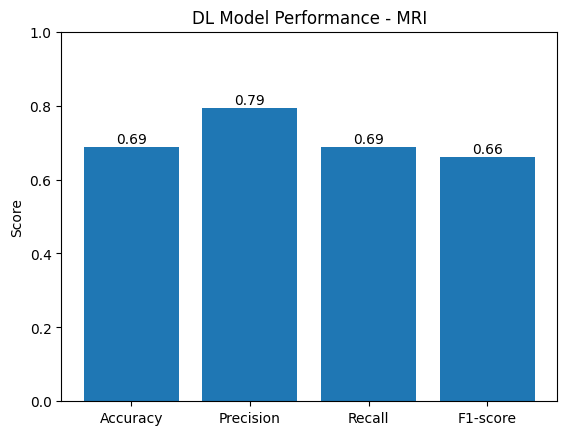

In [27]:
values = [accuracy_dl_mri, precision_dl_mri, recall_dl_mri, f1_dl_mri]

plt.figure()
plt.bar(metrics, values)

plt.title("DL Model Performance - MRI")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

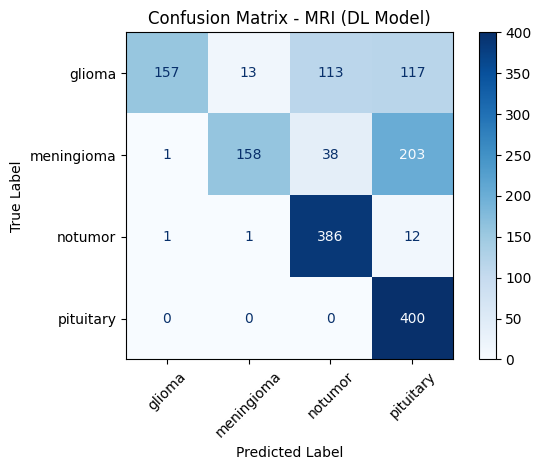

In [28]:
cm_dl_mri = confusion_matrix(y_true_dl_mri, y_pred_dl_mri)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dl_mri,
    display_labels=train_full_mri.classes
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - MRI (DL Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [29]:
feature_extractor_mri = torchvision.models.resnet50(pretrained=True)
feature_extractor_mri.fc = nn.Identity()
feature_extractor_mri = feature_extractor_mri.to(device)
feature_extractor_mri.eval()

def extract_features_mri(loader):
    features, labels_list = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = feature_extractor_mri(images)
            outputs = outputs.view(outputs.size(0), -1)

            features.append(outputs.cpu().numpy())
            labels_list.append(labels.numpy())

    return np.vstack(features), np.hstack(labels_list)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [30]:
X_train_mri, y_train_mri = extract_features_mri(train_loader_mri)
X_test_mri, y_test_mri = extract_features_mri(test_loader_mri)

svm_mri = SVC(kernel='linear', C=1.0)
svm_mri.fit(X_train_mri, y_train_mri)

y_pred_ml_mri = svm_mri.predict(X_test_mri)

In [31]:
print("\n=== MRI SVM RESULTS ===")
print(classification_report(y_test_mri, y_pred_ml_mri))

accuracy_svm_mri = accuracy_score(y_test_mri, y_pred_ml_mri)
precision_svm_mri = precision_score(y_test_mri, y_pred_ml_mri,average='weighted')
recall_svm_mri = recall_score(y_test_mri, y_pred_ml_mri, average='weighted')
f1_svm_mri = f1_score(y_test_mri, y_pred_ml_mri, average='weighted')

print("Accuracy:", accuracy_svm_mri)
print("Precision:", precision_svm_mri)
print("Recall:", recall_svm_mri)
print("F1-score:", f1_svm_mri)


=== MRI SVM RESULTS ===
              precision    recall  f1-score   support

           0       0.88      0.74      0.81       400
           1       0.77      0.86      0.81       400
           2       0.93      0.99      0.96       400
           3       0.96      0.92      0.94       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600

Accuracy: 0.880625
Precision: 0.8841578040769575
Recall: 0.880625
F1-score: 0.8797217796648834


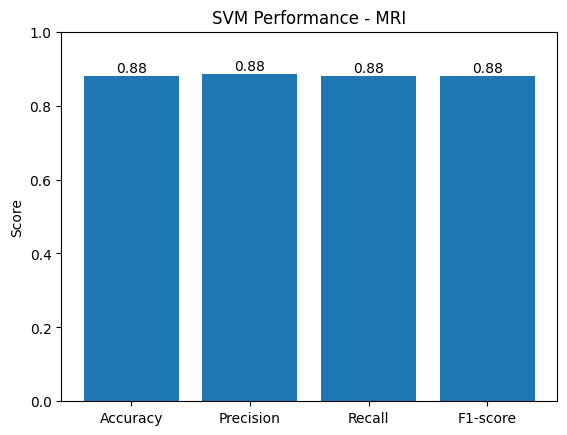

In [32]:
values = [accuracy_svm_mri, precision_svm_mri, recall_svm_mri, f1_svm_mri]

plt.figure()
plt.bar(metrics, values)

plt.title("SVM Performance - MRI")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

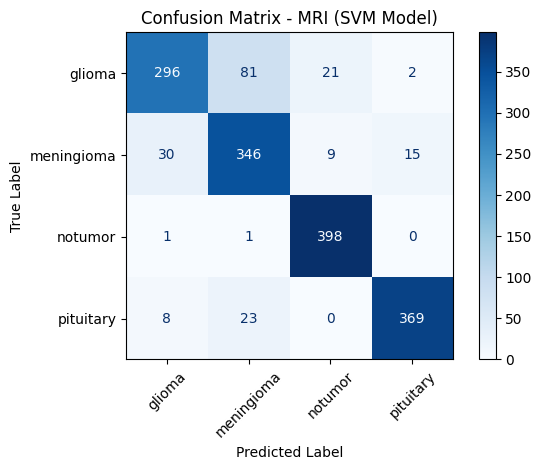

In [33]:
cm_dl_mri = confusion_matrix(y_test_mri, y_pred_ml_mri)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dl_mri,
    display_labels=train_full_mri.classes
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - MRI (SVM Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

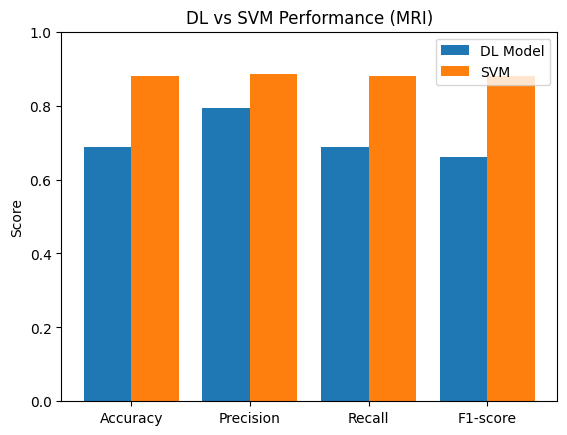

In [34]:
mri_dl_values = [accuracy_dl_mri, precision_dl_mri, recall_dl_mri, f1_dl_mri]
mri_svm_values = [accuracy_svm_mri, precision_svm_mri, recall_svm_mri, f1_svm_mri]

x = range(len(metrics))

plt.figure()

plt.bar(x, mri_dl_values, width=0.4, label='DL Model')
plt.bar([i + 0.4 for i in x], mri_svm_values, width=0.4, label='SVM')

plt.xticks([i + 0.2 for i in x], metrics)
plt.ylim(0, 1)
plt.title("DL vs SVM Performance (MRI)")
plt.ylabel("Score")
plt.legend()

plt.show()

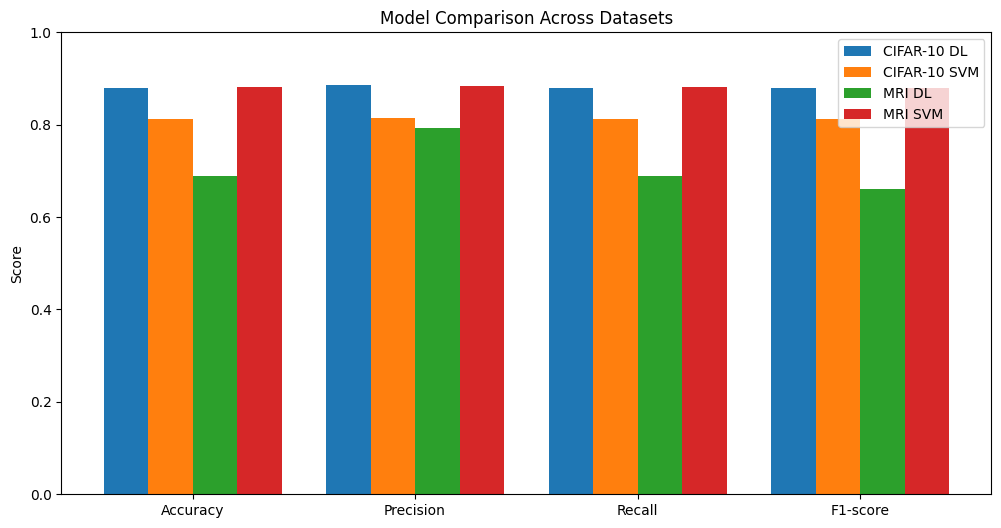

In [35]:
cifar_dl_values = dl_values
cifar_svm_values = svm_values
mri_dl_values = mri_dl_values
mri_svm_values = mri_svm_values

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5*width, cifar_dl_values, width, label='CIFAR-10 DL')
plt.bar(x - 0.5*width, cifar_svm_values, width, label='CIFAR-10 SVM')
plt.bar(x + 0.5*width, mri_dl_values, width, label='MRI DL')
plt.bar(x + 1.5*width, mri_svm_values, width, label='MRI SVM')

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.title("Model Comparison Across Datasets")
plt.ylabel("Score")
plt.legend()

plt.show()